In [1]:
# Importing required librairy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import math

df = pd.read_csv("indonesian_movies.csv")
df.head()

,title,year,description,genre,rating,users_rating,votes,languages,directors,actors,runtime
0,#FriendButMarried 2,2020,Ayudia (Mawar De Jongh) is not satisfied enoug...,Biography,13+,6.5,120,Indonesian,Rako Prijanto,"['Adipati Dolken', 'Mawar Eva de Jongh', 'Vonn...",100 min
1,4 Mantan,2020,"Sara, Airin, Rachel, and Amara were accidental...",Thriller,17+,6.4,8,Indonesian,Hanny Saputra,"['Ranty Maria', 'Jeff Smith', 'Melanie Berentz...",80 min
2,Aku Tahu Kapan Kamu Mati,2020,"After apparent death, Siena is able to see sig...",Horror,13+,5.4,17,Indonesian,Hadrah Daeng Ratu,"['Natasha Wilona', 'Ria Ricis', 'Al Ghazali', ...",92 min
3,Anak Garuda,2020,"Good Morning Indonesia, a school for poor orph...",Adventure,13+,9.1,27,Indonesian,Faozan Rizal,"['Tissa Biani Azzahra', 'Violla Georgie', 'Aji...",129 min
4,Dignitate,2020,Alfi (Al Ghazali) meets Alana (Caitlin Halderm...,Drama,17+,7.6,33,Indonesian,Fajar Nugros,"['Al Ghazali', 'Caitlin Halderman', 'Giorgino ...",109 min


In [2]:
import nltk
nltk.data.path.append(r"C:\Users\tadvi\AppData\Roaming\nltk_data")

from nltk.data import find
print(find('tokenizers/punkt'))


C:\Users\tadvi\AppData\Roaming\nltk_data\tokenizers\punkt


Quick Overview

In [3]:
df.shape

(1272, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272 entries, 0 to 1271
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1272 non-null   object 
 1   year          1272 non-null   int64  
 2   description   840 non-null    object 
 3   genre         1236 non-null   object 
 4   rating        376 non-null    object 
 5   users_rating  1272 non-null   float64
 6   votes         1272 non-null   object 
 7   languages     1272 non-null   object 
 8   directors     1265 non-null   object 
 9   actors        1272 non-null   object 
 10  runtime       869 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 109.4+ KB


In [5]:
df_1 = df.drop(columns=['runtime'])

In [6]:
df_1.isnull().sum()

title             0
year              0
description     432
genre            36
rating          896
users_rating      0
votes             0
languages         0
directors         7
actors            0
dtype: int64

In [7]:
df_1 = df_1.dropna(subset=['description', 'genre', 'directors'], how='all')

In [8]:
df_1 = df_1.dropna(subset=['directors'])

In [9]:
df_1.isnull().sum()

title             0
year              0
description     427
genre            36
rating          891
users_rating      0
votes             0
languages         0
directors         0
actors            0
dtype: int64

In [10]:
df_rating = df_1['rating'].copy()

In [11]:
genre_rating_map = {
    'Animation': 'SU',          # Family-friendly
    'Family': 'SU',             # Suitable for all
    'Comedy': 'PG-13',          # Often mild but can vary
    'Romance': 'PG-13',         # Usually teen/adult themes
    'Drama': '13+',             # Moderate themes
    'Action': '13+',            # Violence, intense scenes
    'Thriller': '17+',          # Mature suspense
    'Horror': '17+',            # Strong violence/scares
    'Documentary': 'Unrated',   # Often not officially rated
    'Sci-Fi': '13+',            # Fantasy/violence, usually teen+
    'Fantasy': '13+',           # Similar to sci-fi
    'Crime': 'R',               # Mature themes
    'Adult': '21+',             # Explicit content
    'Unknown': 'Not Rated'      # Fallback category
}

In [12]:
df_rating = df_1.apply(
    lambda row: genre_rating_map.get(row['genre'], 'Not Rated') if pd.isna(row['rating']) else row['rating'], 
    axis=1
)


In [13]:
df_rating.isnull().sum()

np.int64(0)

In [14]:
df_1 = pd.concat([df_1, df_rating], axis=1)

In [15]:
df_1.head()

,title,year,description,genre,rating,users_rating,votes,languages,directors,actors,0
0,#FriendButMarried 2,2020,Ayudia (Mawar De Jongh) is not satisfied enoug...,Biography,13+,6.5,120,Indonesian,Rako Prijanto,"['Adipati Dolken', 'Mawar Eva de Jongh', 'Vonn...",13+
1,4 Mantan,2020,"Sara, Airin, Rachel, and Amara were accidental...",Thriller,17+,6.4,8,Indonesian,Hanny Saputra,"['Ranty Maria', 'Jeff Smith', 'Melanie Berentz...",17+
2,Aku Tahu Kapan Kamu Mati,2020,"After apparent death, Siena is able to see sig...",Horror,13+,5.4,17,Indonesian,Hadrah Daeng Ratu,"['Natasha Wilona', 'Ria Ricis', 'Al Ghazali', ...",13+
3,Anak Garuda,2020,"Good Morning Indonesia, a school for poor orph...",Adventure,13+,9.1,27,Indonesian,Faozan Rizal,"['Tissa Biani Azzahra', 'Violla Georgie', 'Aji...",13+
4,Dignitate,2020,Alfi (Al Ghazali) meets Alana (Caitlin Halderm...,Drama,17+,7.6,33,Indonesian,Fajar Nugros,"['Al Ghazali', 'Caitlin Halderman', 'Giorgino ...",17+


In [16]:
df_1 = df_1.drop(columns=['rating'])

In [17]:
df_1.head()

,title,year,description,genre,users_rating,votes,languages,directors,actors,0
0,#FriendButMarried 2,2020,Ayudia (Mawar De Jongh) is not satisfied enoug...,Biography,6.5,120,Indonesian,Rako Prijanto,"['Adipati Dolken', 'Mawar Eva de Jongh', 'Vonn...",13+
1,4 Mantan,2020,"Sara, Airin, Rachel, and Amara were accidental...",Thriller,6.4,8,Indonesian,Hanny Saputra,"['Ranty Maria', 'Jeff Smith', 'Melanie Berentz...",17+
2,Aku Tahu Kapan Kamu Mati,2020,"After apparent death, Siena is able to see sig...",Horror,5.4,17,Indonesian,Hadrah Daeng Ratu,"['Natasha Wilona', 'Ria Ricis', 'Al Ghazali', ...",13+
3,Anak Garuda,2020,"Good Morning Indonesia, a school for poor orph...",Adventure,9.1,27,Indonesian,Faozan Rizal,"['Tissa Biani Azzahra', 'Violla Georgie', 'Aji...",13+
4,Dignitate,2020,Alfi (Al Ghazali) meets Alana (Caitlin Halderm...,Drama,7.6,33,Indonesian,Fajar Nugros,"['Al Ghazali', 'Caitlin Halderman', 'Giorgino ...",17+


In [18]:
df_1['directors'] = df_1['directors'].str.replace(" ", "")
df_1['actors'] = df_1['actors'].str.replace(" ", "")

In [19]:
df_1.head()

,title,year,description,genre,users_rating,votes,languages,directors,actors,0
0,#FriendButMarried 2,2020,Ayudia (Mawar De Jongh) is not satisfied enoug...,Biography,6.5,120,Indonesian,RakoPrijanto,"['AdipatiDolken','MawarEvadeJongh','VonnyCorne...",13+
1,4 Mantan,2020,"Sara, Airin, Rachel, and Amara were accidental...",Thriller,6.4,8,Indonesian,HannySaputra,"['RantyMaria','JeffSmith','MelanieBerentz','De...",17+
2,Aku Tahu Kapan Kamu Mati,2020,"After apparent death, Siena is able to see sig...",Horror,5.4,17,Indonesian,HadrahDaengRatu,"['NatashaWilona','RiaRicis','AlGhazali','Fitri...",13+
3,Anak Garuda,2020,"Good Morning Indonesia, a school for poor orph...",Adventure,9.1,27,Indonesian,FaozanRizal,"['TissaBianiAzzahra','ViollaGeorgie','AjilDitt...",13+
4,Dignitate,2020,Alfi (Al Ghazali) meets Alana (Caitlin Halderm...,Drama,7.6,33,Indonesian,FajarNugros,"['AlGhazali','CaitlinHalderman','GiorginoAbrah...",17+


In [20]:
import nltk

# Add your punkt path to NLTK's search list
nltk.data.path.append(r"C:\Users\tadvi\AppData\Roaming\nltk_data")

In [21]:
from nltk.tokenize import sent_tokenize, word_tokenize

In [22]:
copy_df_1 = df_1.copy()

In [23]:
import re

def simple_tokenize(text):
    sentences = re.split(r'[.!?]', str(text))
    return [sentence.strip().split() for sentence in sentences if sentence.strip()]

df_1['description_words'] = df_1['description'].apply(simple_tokenize)


In [24]:
df_1 = df_1.drop(columns=['description'])

In [25]:
df_1.head()

,title,year,genre,users_rating,votes,languages,directors,actors,0,description_words
0,#FriendButMarried 2,2020,Biography,6.5,120,Indonesian,RakoPrijanto,"['AdipatiDolken','MawarEvadeJongh','VonnyCorne...",13+,"[[Ayudia, (Mawar, De, Jongh), is, not, satisfi..."
1,4 Mantan,2020,Thriller,6.4,8,Indonesian,HannySaputra,"['RantyMaria','JeffSmith','MelanieBerentz','De...",17+,"[[Sara,, Airin,, Rachel,, and, Amara, were, ac..."
2,Aku Tahu Kapan Kamu Mati,2020,Horror,5.4,17,Indonesian,HadrahDaengRatu,"['NatashaWilona','RiaRicis','AlGhazali','Fitri...",13+,"[[After, apparent, death,, Siena, is, able, to..."
3,Anak Garuda,2020,Adventure,9.1,27,Indonesian,FaozanRizal,"['TissaBianiAzzahra','ViollaGeorgie','AjilDitt...",13+,"[[Good, Morning, Indonesia,, a, school, for, p..."
4,Dignitate,2020,Drama,7.6,33,Indonesian,FajarNugros,"['AlGhazali','CaitlinHalderman','GiorginoAbrah...",17+,"[[Alfi, (Al, Ghazali), meets, Alana, (Caitlin,..."


In [26]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1265 entries, 0 to 1271
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              1265 non-null   object 
 1   year               1265 non-null   int64  
 2   genre              1229 non-null   object 
 3   users_rating       1265 non-null   float64
 4   votes              1265 non-null   object 
 5   languages          1265 non-null   object 
 6   directors          1265 non-null   object 
 7   actors             1265 non-null   object 
 8   0                  1265 non-null   object 
 9   description_words  1265 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 108.7+ KB


In [27]:
# Append metadata to existing tokenized description_words
def append_metadata(row):
    # Start with the already tokenized description words
    words = list(row['description_words'])  
    
    # Add metadata fields (convert to string to avoid type issues)
    extra_info = [
        str(row['genre']),
        str(row['year']),
        str(row[0]),
        str(row['languages']),
        str(row['directors']),
        str(row['actors'])
    ]
    
    return words + extra_info

df_1['description_words'] = df_1.apply(append_metadata, axis=1)


In [28]:
df_1.head()

,title,year,genre,users_rating,votes,languages,directors,actors,0,description_words
0,#FriendButMarried 2,2020,Biography,6.5,120,Indonesian,RakoPrijanto,"['AdipatiDolken','MawarEvadeJongh','VonnyCorne...",13+,"[[Ayudia, (Mawar, De, Jongh), is, not, satisfi..."
1,4 Mantan,2020,Thriller,6.4,8,Indonesian,HannySaputra,"['RantyMaria','JeffSmith','MelanieBerentz','De...",17+,"[[Sara,, Airin,, Rachel,, and, Amara, were, ac..."
2,Aku Tahu Kapan Kamu Mati,2020,Horror,5.4,17,Indonesian,HadrahDaengRatu,"['NatashaWilona','RiaRicis','AlGhazali','Fitri...",13+,"[[After, apparent, death,, Siena, is, able, to..."
3,Anak Garuda,2020,Adventure,9.1,27,Indonesian,FaozanRizal,"['TissaBianiAzzahra','ViollaGeorgie','AjilDitt...",13+,"[[Good, Morning, Indonesia,, a, school, for, p..."
4,Dignitate,2020,Drama,7.6,33,Indonesian,FajarNugros,"['AlGhazali','CaitlinHalderman','GiorginoAbrah...",17+,"[[Alfi, (Al, Ghazali), meets, Alana, (Caitlin,..."


In [29]:
df_2 = df_1[['title', 'description_words']].copy()

In [30]:
df_2.head()

,title,description_words
0,#FriendButMarried 2,"[[Ayudia, (Mawar, De, Jongh), is, not, satisfi..."
1,4 Mantan,"[[Sara,, Airin,, Rachel,, and, Amara, were, ac..."
2,Aku Tahu Kapan Kamu Mati,"[[After, apparent, death,, Siena, is, able, to..."
3,Anak Garuda,"[[Good, Morning, Indonesia,, a, school, for, p..."
4,Dignitate,"[[Alfi, (Al, Ghazali), meets, Alana, (Caitlin,..."


In [31]:
df_2['description_string'] = df_2['description_words'].apply(
    lambda x: " ".join([word for sublist in x for word in (sublist if isinstance(sublist, list) else [sublist])])
)


In [32]:
df_2 = df_2.drop(columns='description_words')


In [33]:
df_2.head()

,title,description_string
0,#FriendButMarried 2,Ayudia (Mawar De Jongh) is not satisfied enoug...
1,4 Mantan,"Sara, Airin, Rachel, and Amara were accidental..."
2,Aku Tahu Kapan Kamu Mati,"After apparent death, Siena is able to see sig..."
3,Anak Garuda,"Good Morning Indonesia, a school for poor orph..."
4,Dignitate,Alfi (Al Ghazali) meets Alana (Caitlin Halderm...


In [34]:
df_2['description_string'][0]

"Ayudia (Mawar De Jongh) is not satisfied enough in enjoying the moment as a wife, but she suddenly becomes pregnant Her personality changes completely and becomes lazy and super sensitive Biography 2020 13+ Indonesian RakoPrijanto ['AdipatiDolken','MawarEvadeJongh','VonnyCornellya','SariNila','IvanLeonardy','ClayGribble','SarahSechan','JourdyPranata','TubagusAli','RavilPrasetya','NagraKautsarPakusadewo','CantiTachril','ThaliaBasir','SpLili','AnnaTairas']"

In [35]:
print(df_2['description_string'].iloc[0])



Ayudia (Mawar De Jongh) is not satisfied enough in enjoying the moment as a wife, but she suddenly becomes pregnant Her personality changes completely and becomes lazy and super sensitive Biography 2020 13+ Indonesian RakoPrijanto ['AdipatiDolken','MawarEvadeJongh','VonnyCornellya','SariNila','IvanLeonardy','ClayGribble','SarahSechan','JourdyPranata','TubagusAli','RavilPrasetya','NagraKautsarPakusadewo','CantiTachril','ThaliaBasir','SpLili','AnnaTairas']


In [36]:
import re

def clean_string(text):
    # Replace commas with spaces
    text = text.replace(",", " ")
    # Remove brackets and quotes
    text = re.sub(r"[\[\]']", "", text)
    return text

df_2['description_string'] = df_2['description_string'].apply(clean_string)


In [37]:
print(df_2['description_string'].iloc[0])


Ayudia (Mawar De Jongh) is not satisfied enough in enjoying the moment as a wife  but she suddenly becomes pregnant Her personality changes completely and becomes lazy and super sensitive Biography 2020 13+ Indonesian RakoPrijanto AdipatiDolken MawarEvadeJongh VonnyCornellya SariNila IvanLeonardy ClayGribble SarahSechan JourdyPranata TubagusAli RavilPrasetya NagraKautsarPakusadewo CantiTachril ThaliaBasir SpLili AnnaTairas


In [38]:
df_2['description_string'] = df_2['description_string'].apply(lambda x:x.lower())

In [39]:
print(df_2['description_string'].iloc[0])


ayudia (mawar de jongh) is not satisfied enough in enjoying the moment as a wife  but she suddenly becomes pregnant her personality changes completely and becomes lazy and super sensitive biography 2020 13+ indonesian rakoprijanto adipatidolken mawarevadejongh vonnycornellya sarinila ivanleonardy claygribble sarahsechan jourdypranata tubagusali ravilprasetya nagrakautsarpakusadewo cantitachril thaliabasir splili annatairas


In [40]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000,stop_words='english')

In [41]:
vectors = cv.fit_transform(df_2['description_string']).toarray()

In [42]:
vectors[0]

array([0, 0, 0, ..., 0, 0, 0])

In [43]:
cv.get_feature_names_out()

array(['10', '100', '11', ..., 'zulfanny', 'zulkarnaen', 'zulkiflighani'],
      dtype=object)

In [44]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [45]:
def stem(text):
    y = []

    for i in text.split():
        y.append(ps.stem(i))

    return " ".join(y)

In [46]:
stem('ayudia (mawar de jongh) is not satisfied enough in enjoying the moment as a wife  but she suddenly becomes pregnant her personality changes completely and becomes lazy and super sensitive biography 2020 13+ indonesian rakoprijanto adipatidolken mawarevadejongh vonnycornellya sarinila ivanleonardy claygribble sarahsechan jourdypranata tubagusali ravilprasetya nagrakautsarpakusadewo cantitachril thaliabasir splili annatairas')

'ayudia (mawar de jongh) is not satisfi enough in enjoy the moment as a wife but she suddenli becom pregnant her person chang complet and becom lazi and super sensit biographi 2020 13+ indonesian rakoprijanto adipatidolken mawarevadejongh vonnycornellya sarinila ivanleonardi claygribbl sarahsechan jourdypranata tubagusali ravilprasetya nagrakautsarpakusadewo cantitachril thaliabasir splili annataira'

In [47]:
df_2['description_string'] = df_2['description_string'].apply(stem)

In [48]:
vectors = cv.fit_transform(df_2['description_string']).toarray()

In [49]:
vectors[0]

array([0, 0, 0, ..., 0, 0, 0])

In [50]:
from sklearn.metrics.pairwise import cosine_similarity

In [51]:
similarity = cosine_similarity(vectors)

In [52]:
similarity[0]

array([1.        , 0.05986843, 0.09837388, ..., 0.06325346, 0.05914273,
       0.02540003])

In [53]:
def recommend(movie):
    movie_index = df_2[df_2['title'] == movie].index[0]
    distances = similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)),reverse=True,key=lambda x:x[1])[1:6]

    for i in movies_list:
        print(df_2.iloc[i[0]].title)
    return

In [54]:
recommend('Virgin')

Kisah Nyata Kereta Setan Manggarai
Kemasukan Setan
Pacarku Kuntilanak Kembar
Te[rekam]
Pocong Kamar Sebelah


In [55]:
df_3 = df_1[['title', 'users_rating', 'votes']]

In [56]:
df_3.head()

,title,users_rating,votes
0,#FriendButMarried 2,6.5,120
1,4 Mantan,6.4,8
2,Aku Tahu Kapan Kamu Mati,5.4,17
3,Anak Garuda,9.1,27
4,Dignitate,7.6,33


#
𝑅 = movie rating

𝑣 = number of votes

𝐶 = mean rating across all movies

𝑚 = minimum votes threshold (say 300)



In [57]:
print(df_3.dtypes)

title            object
users_rating    float64
votes            object
dtype: object


In [58]:
df_3 = df_3.copy().astype(str)

df_3['votes'] = df_3['votes'].str.replace(',', '')
df_3['votes'] = pd.to_numeric(df_3['votes'], errors='coerce')

In [59]:
df_3['users_rating'] = pd.to_numeric(df_3['users_rating'], errors='coerce')

In [60]:
print(df_3.dtypes)

title            object
users_rating    float64
votes             int64
dtype: object


In [61]:
C = df_3['users_rating'].mean()
m = 300 

def weighted_rating(x, m=m, C=C):
    v = x['votes']
    R = x['users_rating']
    return (v/(v+m) * R) + (m/(v+m) * C)

df_3['weighted_score'] = df_3.apply(weighted_rating, axis=1)

In [62]:
df_3.head()

,title,users_rating,votes,weighted_score
0,#FriendButMarried 2,6.5,120,6.245059
1,4 Mantan,6.4,8,6.149756
2,Aku Tahu Kapan Kamu Mati,5.4,17,6.103233
3,Anak Garuda,9.1,27,6.387232
4,Dignitate,7.6,33,6.287462


In [63]:
scaled_weighted_score = df_3['weighted_score'] / df_3['weighted_score'].max()

In [64]:
print(scaled_weighted_score)

0       0.732056
1       0.720884
2       0.715430
3       0.748721
4       0.737026
          ...   
1266    0.758050
1267    0.722840
1268    0.720637
1269    0.724524
1271    0.724484
Name: weighted_score, Length: 1265, dtype: float64


In [65]:
def recommend2(movie, n=5, alpha=0.7, beta=0.3):
    """
    Recommend movies based on similarity + scaled_weighted_score.
    
    Parameters:
    movie : str - title of the movie
    n : int - number of recommendations
    alpha : float - weight for similarity
    beta : float - weight for weighted_score
    
    Returns:
    DataFrame with recommended movies and scores
    """
    # Find index of the movie
    movie_index = df_2[df_2['title'] == movie].index[0]
    
    # Get similarity scores for this movie
    distances = similarity[movie_index]
    
    
    # Combine similarity and weighted_score
    combined_scores = alpha * distances + beta * scaled_weighted_score
    
    # Sort by combined score
    movies_list = sorted(list(enumerate(combined_scores)), 
                         reverse=True, key=lambda x: x[1])[1:n+1]
    
    # Return recommendations with details
    recs = df_2.iloc[[i[0] for i in movies_list]][['title']]
    return recs


In [74]:
recommend('Virgin')

Kisah Nyata Kereta Setan Manggarai
Kemasukan Setan
Pacarku Kuntilanak Kembar
Te[rekam]
Pocong Kamar Sebelah


In [75]:
recommend2('Virgin')

,title
478,Kemasukan Setan
496,Salisiah Adaik
1023,Bisikan Nafsu
1271,Loetoeng Kasaroeng
773,Kisah Nyata Kereta Setan Manggarai


In [71]:
df_2['scaled_weighted_score'] = scaled_weighted_score

In [72]:
df_2.head()

,title,description_string,scaled_weighted_score
0,#FriendButMarried 2,ayudia (mawar de jongh) is not satisfi enough ...,0.732056
1,4 Mantan,sara airin rachel and amara were accident brou...,0.720884
2,Aku Tahu Kapan Kamu Mati,after appar death siena is abl to see sign tha...,0.715430
3,Anak Garuda,good morn indonesia a school for poor orphan i...,0.748721
4,Dignitate,alfi (al ghazali) meet alana (caitlin halderma...,0.737026


Ranking and relavance metrics


In [76]:
threshold = df_2['scaled_weighted_score'].median()
y_true = (df_2['scaled_weighted_score'] >= threshold).astype(int).values

In [78]:
print(threshold)
print(y_true)

0.7219736969648828
[1 0 0 ... 0 1 1]


In [80]:
from sklearn.metrics.pairwise import cosine_similarity

In [83]:
query_idx = 0
y_score = similarity[query_idx]

In [84]:
print(y_score)

[1.         0.05986843 0.09837388 ... 0.06325346 0.05914273 0.02540003]


In [92]:
def precision_at_k(y_true, y_score, k=20):
    top_k = np.argsort(y_score)[::-1][:k]
    return np.mean(y_true[top_k])

def recall_at_k(y_true, y_score, k=20):
    top_k = np.argsort(y_score)[::-1][:k]
    return np.sum(y_true[top_k]) / np.sum(y_true)

def f1_at_k(y_true, y_score, k=10):
    p = precision_at_k(y_true, y_score, k)
    r = recall_at_k(y_true, y_score, k)
    return 2 * (p * r) / (p + r) if (p+r) > 0 else 0

In [94]:
from sklearn.metrics import ndcg_score

In [95]:
ks = [5, 10, 20, 50]
precisions, recalls, f1s, ndcgs = [], [], [], []

for k in ks:
    precisions.append(precision_at_k(y_true, y_score, k))
    recalls.append(recall_at_k(y_true, y_score, k))
    f1s.append(f1_at_k(y_true, y_score, k))
    ndcgs.append(ndcg_score([y_true], [y_score], k=k))

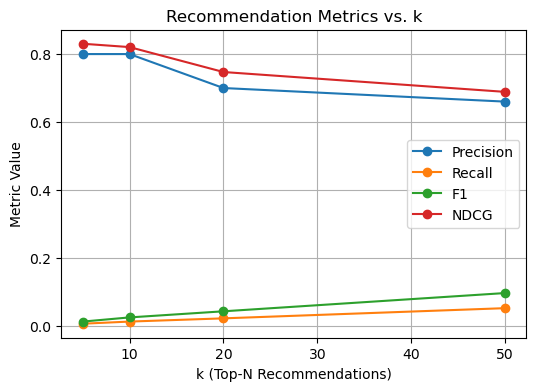

In [97]:
plt.figure(figsize=(6,4))
plt.plot(ks, precisions, marker='o', label="Precision")
plt.plot(ks, recalls, marker='o', label="Recall")
plt.plot(ks, f1s, marker='o', label="F1")
plt.plot(ks, ndcgs, marker='o', label="NDCG")

plt.xlabel("k (Top-N Recommendations)")
plt.ylabel("Metric Value")
plt.title("Recommendation Metrics vs. k")
plt.legend()
plt.grid(True)
plt.show()


In [98]:
results = pd.DataFrame({
    "k": ks,
    "Precision": precisions,
    "Recall": recalls,
    "F1": f1s,
    "NDCG": ndcgs
})

print(results)

    k  Precision    Recall        F1      NDCG
0   5       0.80  0.006319  0.012539  0.830420
1  10       0.80  0.012638  0.024883  0.820523
2  20       0.70  0.022117  0.042879  0.747146
3  50       0.66  0.052133  0.096633  0.688683
